# Econ 8208 Assignment 4

- Author: Yuxuan Zhao
- Date: 2026-03-27

In [2]:
using LinearAlgebra
# Using defined functions in ECON8208Tools.jl
include("../ECON8208Tools.jl")
using .ECON8208Tools


# LHW 4

We are given

- a return function $r(x,u)$, where $x \in \mathbb{R}^n$ and $u \in \mathbb{R}^m$,
- a state transition function $g(x,u)$,
- a steady state $(\bar x, \bar u)$.

We first construct the matrices for the standard local LQ approximation:
$$
\begin{aligned}
r(x,u) &\approx r(\bar x,\bar u) + \hat x' Q \hat x + 2 \hat x' W \hat u + \hat u' R \hat u, \\
\hat x_{t+1} &= A \hat x_t + B \hat u_t, \\
\hat x &= x-\bar x, \quad \hat u = u-\bar u. \\
\end{aligned}
$$


Then we need to compute the following matrices:
$$
Q = \frac{1}{2} r_{xx}(\bar x,\bar u), \qquad
W = \frac{1}{2} r_{xu}(\bar x,\bar u), \qquad
R = \frac{1}{2} r_{uu}(\bar x,\bar u),
$$
and
$$
A = g_x(\bar x,\bar u), \qquad B = g_u(\bar x,\bar u).
$$

Given the matrices from the local LQ approximation:
$$
Q, \quad W, \quad R, \quad A, \quad B,
$$
together with the discount factor $\beta$.

The problem is to solve the infinite-horizon LQ problem:
$$
\hat V(\hat x) = \max_{\{\hat u_t\}} \sum_{t=0}^{\infty} \beta^t
\left(
\hat x_t' Q \hat x_t + 2 \hat x_t' W \hat u_t + \hat u_t' R \hat u_t
\right)
$$
subject to
$$
\hat x_{t+1} = A \hat x_t + B \hat u_t.
$$

Because the return is quadratic and the law of motion is linear, we guess that the value function takes the quadratic form
$$
\hat V(\hat x) = \hat x' P \hat x.
$$

Substituting this guess into the Bellman equation and taking the first-order condition with respect to $\hat u$, we obtain the policy rule
$$
\hat u = -F \hat x,
$$
where
$$
F = \left(R + \beta B' P B\right)^{-1}\left(W' + \beta B' P A\right).
$$

Substituting the policy rule back into the Bellman equation gives the Riccati equation:
$$
P
=
Q - F'W' - WF + F'RF + \beta (A - BF)' P (A - BF).
$$

We solve this equation by fixed-point iteration.

### HW 4: One-Sector Growth Model

As a simple economic example, we consider the deterministic one-sector growth model in Homework 4.

The planner's problem is:
$$
\begin{aligned}
\max_{\{c_t,k_{t+1}\}} \quad & \sum_{t=0}^{\infty} \beta^t \log(c_t) \\
\text{s.t.} \quad & c_t + k_{t+1} = A k_t^\theta, \\
& k_0 \text{ given.}
\end{aligned}
$$

Using the resource constraint to substitute out consumption, the problem can be rewritten as
$$
\begin{aligned}
\max_{\{k_{t+1}\}} \quad & \sum_{t=0}^{\infty} \beta^t \log\!\left(A k_t^\theta - k_{t+1}\right) \\
\text{s.t.} \quad & k_0 \text{ given.}
\end{aligned}
$$


We can derive the Euler equation:
$$
\frac{1}{c_t} = \beta \frac{1}{c_{t+1}} A \theta k_{t+1}^{\theta-1}.
$$

### Steady State

In steady state, we have $k_{t+1} = k_t = \bar k$ and $c_t = c_{t+1} = \bar c$, then:

$$
\frac{1}{\bar c}
=
\beta \frac{1}{\bar c} A \theta \bar k^{\theta-1},
$$

Solving for steady-state capital gives
$$
\bar k = (\beta A \theta)^{\frac{1}{1-\theta}}.
$$

Steady-state consumption is therefore
$$
\bar c = A \bar k^\theta - \bar k.
$$


We let
$$
x = k_t, \qquad u = k_{t+1}.
$$

Then the return function and transition function are
$$
\begin{aligned}
r(x,u) &= \log\!\left(Ax^\theta - u\right), \\
g(x,u) &= u, \\
\bar x &= \bar k, \\
\bar u &= \bar k.
\end{aligned}
$$

We can then evaluate the matrices $Q, W, R, A, B$ at $(\bar x,\bar u)$ and use them as inputs for the Riccati solver.


In [3]:
# -------------------------------------------------------
# Example: one-sector growth model in HW4
# Variables:
#   state   x = current capital k_t
#   control u = next-period capital k_{t+1}
# Functions:
#   return function: r(x, u) = log(c) where c = Aprod * x[1]^θ - u[1]
#   transition function: g(x, u) = u
# Steady state:
#   xbar = kbar
#   ubar = kbar
# -------------------------------------------------------

Aprod = 1.0
θ = 0.36
β = 0.95
h = 1e-6

# Return function and transition function
r(x, u) = log(Aprod * x[1]^θ - u[1])
g(x, u) = [u[1]]

# Steady state
kbar = (β * Aprod * θ)^(1.0 / (1.0 - θ))
cbar = Aprod * kbar^θ - kbar

xbar = [kbar]
ubar = [kbar]

println("steady-state capital = ", kbar)
println("steady-state consumption = ", cbar)

# Construct local LQ approximation
Q, W, R, A, B = lq_approximation(r, g, xbar, ubar; h=h)

println("Q = ")
println(Q)

println("W = ")
println(W)

println("R = ")
println(R)

println("A = ")
println(A)

println("B = ")
println(B)

# Solve Riccati equation
F, P = solve_riccati(Q, W, R, A, B, β)

println("F = ")
println(F)

println("P = ")
println(P)


steady-state capital = 0.18703194520402705
steady-state consumption = 0.359845087556286
Q = 
[-9.283240842705709;;]
W = 
[4.064582004303929;;]
R = 
[-3.8613556796462944;;]
A = 
[0.0;;]
B = 
[1.000000000001;;]
F = 
[-0.36000575014493913;;]
P = 
[-7.819967949220652;;]


Note that, under the current specification
$$
\begin{aligned}
r(x,u) &= \log\!\left(Ax^\theta - u\right), \\
g(x,u) &= u, \\
\bar x &= \bar k, \\
\bar u &= \bar k.
\end{aligned}
$$
the implied steady-state consumption is
$$
\bar c = A \bar k^\theta - \bar k
$$

We want to plot the equilibrium paths for consumption $\{c_t\}_{t=0}^\infty$, capital $\{k_t\}_{t=0}^\infty$, and output $\{y_t\}_{t=0}^\infty$

At period $t=0$, the economy starts from an initial capital stock of 
$$
k_0 = \frac{\bar k}{2},
$$
and we can then use the policy function implied by the Riccati solution $F$ to iterate forward the paths of capital, consumption, and output over time.

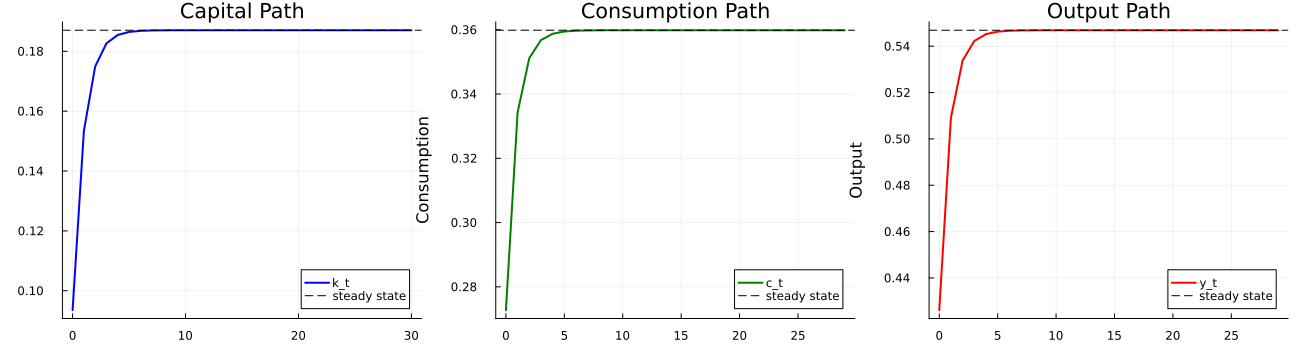

In [4]:
using Plots

# -------------------------------------------------------
# Simulate the equilibrium path for HW4
# Initial condition: k0 = kbar / 2
# Policy rule: \hat u_t = -F \hat x_t, where u_t = k_{t+1}
# Then recover the level paths for capital, consumption, and output
# -------------------------------------------------------

T = 30

# Initial capital level
k0 = kbar / 2.0
khat0 = k0 - kbar

# Extract scalar values from 1x1 matrices
A1 = A[1, 1]
B1 = B[1, 1]
F1 = F[1, 1]

# Closed-loop coefficient
Acl = A1 - B1 * F1

# Allocate arrays
khat = zeros(T + 1)
uhat = zeros(T)
k = zeros(T + 1)
kp = zeros(T)
c = zeros(T)
y = zeros(T)

# Set initial condition
khat[1] = khat0
k[1] = k0

# Simulate the path
for t in 1:T
    uhat[t] = -F1 * khat[t]
    khat[t + 1] = Acl * khat[t]

    # Recover next-period capital from the decision rule
    kp[t] = kbar + uhat[t]

    # Recover current-period output and consumption
    y[t] = Aprod * k[t]^θ
    c[t] = y[t] - kp[t]

    # Update the capital path
    k[t + 1] = kp[t]
end

# Time indices
tk = 0:T
ti = 0:(T - 1)

# Steady-state output
ybar = Aprod * kbar^θ

# -------------------------------------------------------
# Plot capital path with steady-state line
# -------------------------------------------------------
p1 = plot(
    tk, k,
    label = "k_t",
    linewidth = 2,
    color = :blue,
    xlabel = "t",
    ylabel = "Capital",
    title = "Capital Path"
)

hline!(p1, [kbar], linestyle = :dash, color = :black, label = "steady state")

# -------------------------------------------------------
# Plot consumption path with steady-state line
# -------------------------------------------------------
p2 = plot(
    ti, c,
    label = "c_t",
    linewidth = 2,
    color = :green,
    xlabel = "t",
    ylabel = "Consumption",
    title = "Consumption Path"
)

hline!(p2, [cbar], linestyle = :dash, color = :black, label = "steady state")

# -------------------------------------------------------
# Plot output path with steady-state line
# -------------------------------------------------------
p3 = plot(
    ti, y,
    label = "y_t",
    linewidth = 2,
    color = :red,
    xlabel = "t",
    ylabel = "Output",
    title = "Output Path"
)

hline!(p3, [ybar], linestyle = :dash, color = :black, label = "steady state")

plot(p1, p2, p3, layout = (1, 3), size = (1300, 350))
